In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 100)
plt.rcParams["figure.figsize"] = (9, 5)

DATA_DIR = "/kaggle/input/datasets/ankurzing/sentiment-analysis-for-financial-news"

In [2]:
df = pd.read_csv(
    os.path.join(DATA_DIR, "all-data.csv"),
    encoding="latin-1",
    header=None,
    names=["sentiment", "headline"],
)

df

,sentiment,headline
0,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is..."
1,neutral,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to..."
2,negative,The international electronic industry company Elcoteq has laid off tens of employees from its Ta...
3,positive,With the new production plant the company would increase its capacity to meet the expected incre...
4,positive,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-te..."
...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower in London Monday as a rebound in bank stocks fail...
4842,neutral,"Rinkuskiai 's beer sales fell by 6.5 per cent to 4.16 million litres , while Kauno Alus ' beer s..."
4843,negative,"Operating profit fell to EUR 35.4 mn from EUR 68.8 mn in 2007 , including vessel sales gain of E..."
4844,negative,Net sales of the Paper segment decreased to EUR 221.6 mn in the second quarter of 2009 from EUR ...


In [3]:
df.isna().sum()

sentiment    0
headline     0
dtype: int64

In [4]:
print("Shape:", df.shape)
df.info()

Shape: (4846, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  4846 non-null   object
 1   headline   4846 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


In [5]:
df.describe()

,sentiment,headline
count,4846,4846
unique,3,4838
top,neutral,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sells stake in Morning Digital Design Oy Finnish IT c...
freq,2879,2


In [6]:
df.isna().sum()

sentiment    0
headline     0
dtype: int64

# Visualize the label distribution

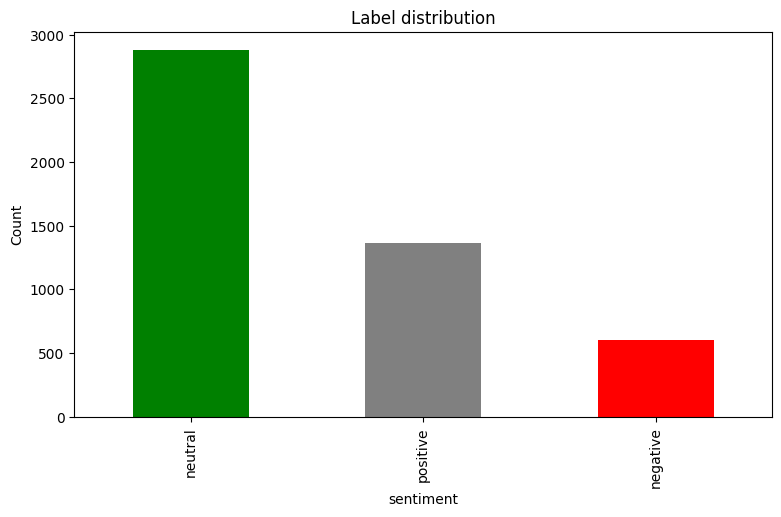

In [7]:
df["sentiment"].value_counts().plot(kind="bar", title="Label distribution", color=["green", "grey", "red"])
plt.ylabel("Count")
plt.show()

In [8]:
df["headline_length"] = df["headline"].str.split().apply(len)
df.groupby("sentiment")["headline_length"].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,604.0,23.917219,9.887414,5.0,17.0,22.0,30.0,56.0
neutral,2879.0,22.176450,9.815893,2.0,15.0,21.0,28.0,81.0
positive,1363.0,24.692590,10.062878,5.0,17.0,23.0,31.0,57.0


In [9]:
df["sentiment"].value_counts(normalize=True)

sentiment
neutral     0.594098
positive    0.281263
negative    0.124639
Name: proportion, dtype: float64

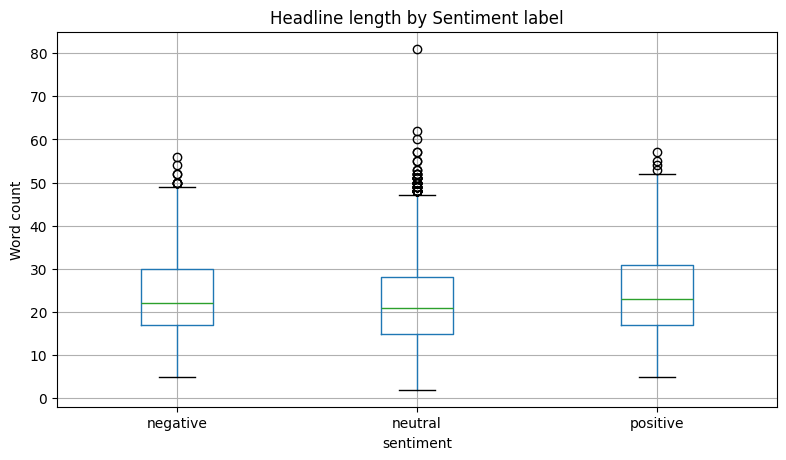

In [10]:
df.boxplot(column="headline_length", by="sentiment")
plt.title("Headline length by Sentiment label")
plt.suptitle("")
plt.ylabel("Word count")
plt.show()

In [11]:
def remove_outliers(group):
    Q1 = group["headline_length"].quantile(0.25)
    Q3 = group["headline_length"].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return group[(group["headline_length"] >= lower) &
                 (group["headline_length"] <= upper)]

df = (
    df.groupby("sentiment", group_keys=False)
      .apply(remove_outliers)
      .reset_index(drop=True)
)

/tmp/ipykernel_16/1820203040.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)


# 3. A transparent, lexicon-based sentiment scorer

In [12]:
pos_freq = {}
neg_freq = {}

for _, row in df.iterrows():
    sentiment = row["sentiment"]

    if sentiment == "neutral":
        continue

    words = {
        w.strip(".,!?:;()'\"").lower()
        for w in row["headline"].split()
    }

    if sentiment == "positive":
        for word in words:
            if word not in pos_freq:
                pos_freq[word] = 0
            pos_freq[word] += 1
    else:
        for word in words:
            if word not in neg_freq:
                neg_freq[word] = 0
            neg_freq[word] += 1

POSITIVE_WORDS = set()
NEGATIVE_WORDS = set()
NEUTRAL_WORDS = set()

THRESHOLD = 0.9

all_words = set(pos_freq.keys()) | set(neg_freq.keys())

for word in all_words:
    p = pos_freq[word] if word in pos_freq else 0
    n = neg_freq[word] if word in neg_freq else 0

    # Pure numbers are always neutral
    if word.replace(".", "").replace(",", "").isdigit():
        NEUTRAL_WORDS.add(word)
        continue

    if p + n < 10:
        continue

    if abs(p - n) / (p + n) <= THRESHOLD:
        NEUTRAL_WORDS.add(word)
    elif p > n:
        POSITIVE_WORDS.add(word)
    else:
        NEGATIVE_WORDS.add(word)

In [13]:
print(*sorted(POSITIVE_WORDS), sep=", ")
print("\n length of POSITIVE_WORDS",len(POSITIVE_WORDS))

able, acquisition, agreement, aim, aims, awarded, base, both, buy, cooperation, deliver, efficient, europe, expand, expansion, focus, global, good, grew, head, improve, improved, increase, july, leading, line, markets, narrowed, order, pleased, position, positive, presence, press, program, provide, record, respectively, rise, rose, savings, says, services, signed, significant, strategic, strategy, strengthen, strong, transaction, won, worth

 length of POSITIVE_WORDS 52


In [14]:
print(*sorted(NEGATIVE_WORDS), sep=", ")
print("\n length of NEGATIVE_WORDS",len(NEGATIVE_WORDS))

below, decreased, down, fell, lay-offs, scanfil, slipped, temporarily, warning

 length of NEGATIVE_WORDS 9


In [15]:
print(*sorted(NEUTRAL_WORDS), sep=", ")
print("\n length of NEUTRAL_WORDS",len(NEUTRAL_WORDS))

, $, %, &, -, --, 0, 0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.08, 0.09, 0.1, 0.11, 0.12, 0.15, 0.16, 0.17, 0.18, 0.2, 0.20, 0.21, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.30, 0.31, 0.32, 0.33, 0.34, 0.36, 0.37, 0.38, 0.4, 0.40, 0.42, 0.43, 0.44, 0.47, 0.48, 0.5, 0.50, 0.52, 0.56, 0.6, 0.63, 0.64, 0.66, 0.67, 0.7, 0.78, 0.8, 0.80, 0.81, 0.83, 0.86, 0.87, 0.9, 0.90, 0.91, 0.92, 00, 000, 01, 02, 03, 04, 04.01.2006, 05, 06, 07, 08, 083, 09, 09.30, 0941, 1, 1,000, 1,007, 1,019, 1,027.0, 1,047.4, 1,050.7, 1,064.14, 1,070.6, 1,084.47, 1,100, 1,125.60, 1,132,000, 1,138.84, 1,155,000, 1,173, 1,200, 1,244.4, 1,259.6, 1,259.7, 1,300, 1,408, 1,425.1, 1,500, 1,553, 1,566, 1,600, 1,700, 1,800, 1.0, 1.00, 1.002, 1.02, 1.03, 1.045, 1.05, 1.1, 1.10, 1.13, 1.14, 1.15, 1.2, 1.20, 1.21, 1.22, 1.29, 1.3, 1.33, 1.343, 1.35, 1.37, 1.4, 1.42, 1.5, 1.523, 1.6, 1.62, 1.67, 1.68, 1.7, 1.70, 1.71, 1.76, 1.8, 1.9, 1.94, 10, 10,000, 10,321.46, 10,530.74, 10,736.42, 10.1, 10.14, 10.2, 10.30, 10.33, 10.4, 10.44, 10.46, 10.5,

In [16]:
# Score a headline
def score_headline(headline: str):
    words = {
        w.strip(".,!?:;()'\"").lower()
        for w in headline.split()
    } - NEUTRAL_WORDS

    pos = len(words & POSITIVE_WORDS)
    neg = len(words & NEGATIVE_WORDS)

    return pos - neg, pos, neg

pos_threshold = 1
neg_threshold = 0

def label_from_score(result):
    score, pos, neg = result

    if score > pos_threshold:
        return "positive"
    if score < neg_threshold:
        return "negative"

    return "neutral"

# Predict
df["score_tuple"] = df["headline"].apply(score_headline)
df["lexicon_score"] = df["score_tuple"].apply(lambda x: x[0])
df["lexicon_label"] = df["score_tuple"].apply(label_from_score)

df[["headline", "sentiment", "lexicon_score", "lexicon_label"]].head(30)

,headline,sentiment,lexicon_score,lexicon_label
0,The international electronic industry company Elcoteq has laid off tens of employees from its Ta...,negative,0,neutral
1,A tinyurl link takes users to a scamming site promising that users can earn thousands of dollars...,negative,0,neutral
2,"Compared with the FTSE 100 index , which rose 36.7 points ( or 0.6 % ) on the day , this was a r...",negative,1,neutral
3,"Compared with the FTSE 100 index , which rose 94.9 points ( or 1.6 % ) on the day , this was a r...",negative,1,neutral
4,One of the challenges in the oil production in the North Sea is scale formation that can plug pi...,negative,0,neutral
5,Jan. 6 -- Ford is struggling in the face of slowing truck and SUV sales and a surfeit of up-to-d...,negative,0,neutral
6,Peer Peugeot fell 0.81 pct as its sales rose only 6.3 pct from the same period last year .,negative,0,neutral
7,Pharmaceuticals group Orion Corp reported a fall in its third-quarter earnings that were hit by ...,negative,0,neutral
8,"However , the growth margin slowed down due to the financial crisis .",negative,-1,negative
9,"2009 3 February 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , s...",negative,-1,negative


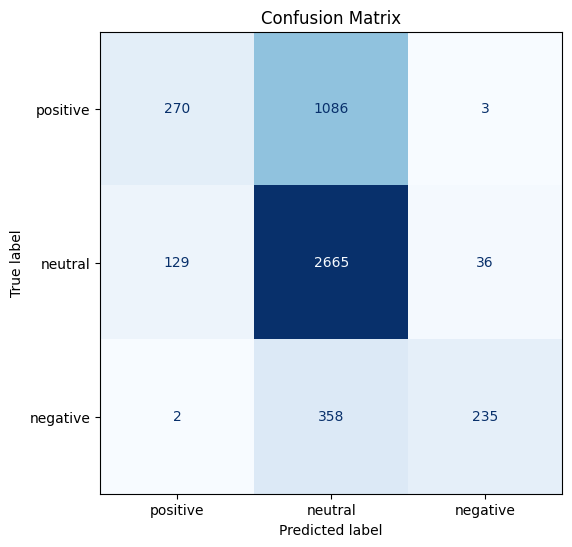

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["positive", "neutral", "negative"]

cm = confusion_matrix(
    df["sentiment"],
    df["lexicon_label"],
    labels=labels
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

In [18]:
accuracy = (df["lexicon_label"] == df["sentiment"]).mean()
print(f"Lexicon vs ground truth accuracy: {accuracy}")

Lexicon vs ground truth accuracy: 0.6626254180602007


In [19]:
mismatches = df[df["lexicon_label"] != df["sentiment"]]
mismatches[["headline", "sentiment", "lexicon_label"]].sample(min(10, len(mismatches)), random_state=42)

,headline,sentiment,lexicon_label
189,"The poorest index figure was given to Finnish power company Fortum , 4.5 .",negative,neutral
4392,One of my colleagues summed up the E7 quite aptly when he remarked : `` Fantastic hardware .,positive,neutral
4178,Strong growth has continued also in China .,positive,neutral
4025,Finnish forest machinery manufacturer Ponsse has agreed with Volvo on the start of cooperation i...,positive,neutral
3769,The economic occupancy rate of Sponda 's property portfolio rose to 91.2 % from 88.8 % in 2006 .,positive,neutral
4647,Consumer products manufacturer Fiskars Corp. will open a distribution and warehouse center in So...,positive,neutral
4749,"I use natural fibers to make the clothes more comfortable , to allow your skin to breathe and to...",positive,neutral
708,"The order consists of capacity expansion , maintenance services and new charging functionality ,...",neutral,positive
3921,The loss for the third quarter of 2007 was EUR 0.3 mn smaller than the loss of the second quarte...,positive,neutral
344,"The EU Commission said earlier it had fined ThyssenKrupp , United Technologies Corp 's Otis , Sc...",negative,neutral


In [20]:
def predict_label(score, pos_threshold, neg_threshold):
    if score > pos_threshold:
        return "positive"
    if score < neg_threshold:
        return "negative"
    return "neutral"


best_acc = -1
best_params = None

for freq_threshold in [i / 10 for i in range(1, 10)]:

    # Build lexicons once for this frequency threshold
    POSITIVE_WORDS = set()
    NEGATIVE_WORDS = set()
    NEUTRAL_WORDS = set()

    for word in all_words:
        p = pos_freq.get(word, 0)
        n = neg_freq.get(word, 0)

        if word.replace(".", "").replace(",", "").isdigit():
            NEUTRAL_WORDS.add(word)
            continue

        if p + n < 10:
            continue

        if abs(p - n) / (p + n) <= freq_threshold:
            NEUTRAL_WORDS.add(word)
        elif p > n:
            POSITIVE_WORDS.add(word)
        else:
            NEGATIVE_WORDS.add(word)

    # Score each headline once for this lexicon
    scores = [
        score_headline(headline)[0]
        for headline in df["headline"]
    ]

    # Search thresholds
    for pos_threshold in range(-10, 22):
        for neg_threshold in range(-20, 12):

            if pos_threshold < neg_threshold:
                continue

            labels = [
                predict_label(score, pos_threshold, neg_threshold)
                for score in scores
            ]

            acc = (df["sentiment"] == labels).mean()

            if acc > best_acc:
                best_acc = acc
                best_params = (
                    freq_threshold,
                    pos_threshold,
                    neg_threshold
                )

print(f"Best accuracy: {best_acc:.4f}")
print(f"Best frequency threshold: {best_params[0]}")
print(f"Best positive threshold: {best_params[1]}")
print(f"Best negative threshold: {best_params[2]}")

Best accuracy: 0.6626
Best frequency threshold: 0.9
Best positive threshold: 1
Best negative threshold: 0
